## Parte 1 — Análise Exploratória de Dados (EDA)

1. Carregamento do dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# configuração de visual
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv('../data/creditcard.csv')

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


2. Estrutura geral dos dados

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Análise:

O dataset possui 284.807 registros e 31 colunas

Não há valores nulos

As variáveis são majoritariamente numéricas (float64)

A variável alvo (Class) é do tipo inteiro (int64)

3. Natureza das variáveis

As variáveis V1 a V28 foram transformadas por meio de PCA (Principal Component Analysis), o que impede sua interpretação direta, mas preserva padrões relevantes para modelagem.

Além disso:

```
Time: representa o tempo em segundos desde a primeira transação
Amount: valor da transação
Class: variável alvo (0 = normal, 1 = fraude)
```

4. Distribuição da variável alvo

Analisamos a quantidade de transações normais e fraudulentas.

In [6]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

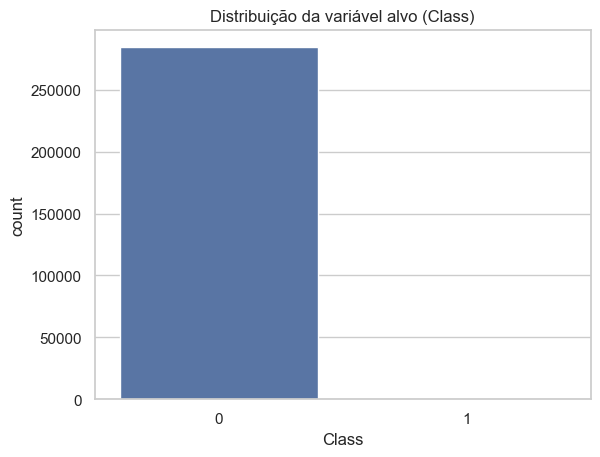

In [7]:
sns.countplot(x='Class', data=df)
plt.title('Distribuição da variável alvo (Class)')
plt.show()

Análise do desbalanceamento:

A grande maioria das transações pertence à classe 0 (normal)

A classe 1 (fraude) representa uma parcela extremamente
pequena do dataset

Isso caracteriza um problema de forte desbalanceamento

5. Escala das variáveis

As variáveis V1 a V28 já estão normalizadas devido ao uso de PCA. No entanto, a variável Amount possui uma escala diferente e pode influenciar modelos baseados em distância ou regressão.

6. Discussão

**Por que esse problema é desafiador?**

O problema é desafiador devido ao forte desbalanceamento entre as classes. Como as fraudes representam uma pequena fração dos dados, o modelo pode ter dificuldade em aprender padrões relevantes para identificá-las.

**Por que acurácia não é uma boa métrica?**

A acurácia não é adequada neste contexto, pois um modelo pode obter alta acurácia simplesmente classificando todas as transações como normais, ignorando completamente as fraudes.

Ele pode alcançar aproximadamente 99.8% de acurácia, evidenciando que essa métrica não é adequada para problemas com forte desbalanceamento.